# PEFT LoRA 실습 : 한국어 QA Fine-tuning

**데이터** : KorQuAD 1.0 (한국어 SQuAD)
**모델** : Qwen/Qwen2.5-0.5B

학습 후 모델이 **정답만 짧게** answer 하도록 만드는 것이 목표입니다.

> ⚙️ 런타임 → 런타임 유형 변경 → **T4 GPU** 선택


## 0. 환경 설정

In [1]:
!pip install -q -U peft accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.2 MB/s eta 0:00:00


torchao는 PyTorch 모델 최적화·양자화 패키지이며, 이번 LoRA 실습에는 필요 없고 버전 충돌 가능성이 있어서 제거

In [2]:
# torchao 버전 충돌 정리 (이 실습에는 불필요한 패키지)
import importlib, importlib.util, subprocess, sys

def torchao_version():
    try:
        from importlib.metadata import version
        return version("torchao")
    except Exception:
        return None

v = torchao_version()
print(f"현재 torchao: {v}")

if v is not None:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"],
                   check=False)
    importlib.invalidate_caches()
    print("→ torchao 제거 완료")
else:
    print("→ torchao 없음, 조치 불필요")

# PEFT 정상 로드 확인
try:
    from peft import LoraConfig, get_peft_model
    import peft
    print(f"\n✅ PEFT {peft.__version__} 로드 성공")
except ImportError as e:
    print(f"\n❌ 아직 오류가 남아 있습니다:\n{e}")
    print("\n→ 상단 메뉴 [런타임] → [세션 다시 시작] 후 이 셀부터 다시 실행하세요.")

현재 torchao: 0.10.0
→ torchao 제거 완료

✅ PEFT 0.20.0 로드 성공


In [3]:
import torch, re, random
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

사용 디바이스: cuda
GPU: Tesla T4
VRAM: 14.6 GB


## 1. 설정값

이 셀의 값만 바꾸면 실험 조건을 조절할 수 있습니다.

In [4]:
MODEL_NAME  = "Qwen/Qwen2.5-0.5B"   # 더 좋은 결과를 원하면 "Qwen/Qwen2.5-1.5B"

TRAIN_SIZE  = 5000     # 학습 샘플 수
EVAL_SIZE   = 300      # 평가 샘플 수
CTX_CHARS   = 300      # 문맥으로 사용할 글자 수 (정답 주변을 잘라낸다)
MAX_LENGTH  = 384      # 토큰 기준 최대 길이

LORA_R      = 16
LORA_ALPHA  = 32       # alpha / r = 2 가 일반적인 기본값
LORA_DROPOUT= 0.05

EPOCHS      = 3
LR          = 2e-4
BATCH       = 4
ACCUM       = 4        # 실질 배치 = BATCH * ACCUM = 16

print("설정 완료")

설정 완료


## 2. 모델 · 토크나이저 로드

> **중요** : 학습할 모델은 **fp32 로 로드**합니다.
> fp16 으로 로드한 모델을 fp16 으로 학습시키면 gradient 가 제대로 반영되지 않아
> loss 가 떨어지지 않는 일이 흔합니다. 혼합 정밀도(fp16)는 Trainer 옵션으로만 켭니다.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# 사전학습 모델에 맞는 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# pad_token이 정의되어 있지 않은 모델의 경우 eos_token을 padding 토큰으로 사용
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 다음 토큰 예측 방식의 GPT 계열 모델에 사용하는 클래스
# 모델 가중치를 float32 정밀도로 로드
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
).to(device)

# 모델 설정에도 tokenizer와 동일한 padding token ID 지정
model.config.pad_token_id = tokenizer.pad_token_id

# 학습 중에는 KV cache를 사용하지 않도록 비활성화
model.config.use_cache = False

print(f"모델: {MODEL_NAME}")
print(f"파라미터 수: {model.num_parameters():,}")
print(f"vocab 크기: {len(tokenizer):,}")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

모델: Qwen/Qwen2.5-0.5B
파라미터 수: 494,032,768
vocab 크기: 151,665


## 3. LoRA adapter 주입

LoRA는 모델 전체를 다시 학습하지 않고, 모델 안의 중요한 일부 층에만 작은 학습용 부품(adapter)을 붙여서 그 부분만 학습합니다.

여기서 target_modules는 “LoRA adapter를 어디에 붙일 것인가”를 지정하는 목록입니다.  

원본 모델은 그대로 두고 Attention과 MLP의 주요 층에 작은 LoRA 학습 모듈만 추가합니다

In [6]:
from peft import LoraConfig, TaskType, get_peft_model

# LoRA 학습 설정 정의
lora_config = LoraConfig(
    r=LORA_R,       # LoRA의 rank - 원래 큰 가중치 행렬의 업데이트를 저차원 행렬로 분해할 때의 차원 크기
    lora_alpha=LORA_ALPHA,  # LoRA 업데이트의 크기를 조절하는 스케일 계수
    lora_dropout=LORA_DROPOUT,       # LoRA 경로에 적용할 dropout 비율

    # LoRA를 적용할 모델 내부의 Linear Layer 지정
    # q_proj, k_proj, v_proj, o_proj  → Self-Attention의 Query, Key, Value, Output projection
    # gate_proj, up_proj, down_proj  → Transformer의 FFN/MLP 영역에 있는 projection layer
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    task_type=TaskType.CAUSAL_LM,    # Causal Language Modeling임을 지정
)

# 기존 사전학습 모델에 LoRA Adapter를 삽입
lora_model = get_peft_model(model, lora_config)

# 전체 파라미터 중 실제로 학습되는 LoRA 파라미터 수와 비율 출력
lora_model.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


## 4. 데이터 준비

### 4-1. KorQuAD 로드

In [7]:
from datasets import load_dataset

raw = load_dataset("KorQuAD/squad_kor_v1", split="train").shuffle(seed=42)
print(f"전체 학습 데이터: {len(raw):,}개")

ex = raw[0]
print(f"\n문맥(앞 120자): {ex['context'][:120]}...")
print(f"질문: {ex['question']}")
print(f"답변: {ex['answers']['text'][0]}")
print(f"정답 위치(글자): {ex['answers']['answer_start'][0]}")

README.md:   0%|          | 0.00/6.29k [00:00<?, ?B/s]

squad_kor_v1/train-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 11.6MB            

squad_kor_v1/train-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

squad_kor_v1/validation-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 1.16MB            

squad_kor_v1/validation-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60407 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5774 [00:00<?, ? examples/s]

전체 학습 데이터: 60,407개

문맥(앞 120자): 9월 26일 환경부를 비롯한 12개 관계부처가 합동으로 '미세먼지 관리 종합대책'을 확정하고 발전·산업·수송·생활 등 4개 부분에서 저감 대책을 실시하는 관련 로드맵을 발표했다. 7조 2000억 원의 예산을 투입해 ...
질문: 미세먼지 해결을 위해 전국으로 확대 강화된 기존의 제도는?
답변: 대기배출총량제
정답 위치(글자): 290


### 4-2. 정답이 잘리지 않도록 문맥을 자른다  ⭐

 `answer_start` 를 이용해 **정답을 가운데 두고** 문맥을 잘라냅니다.

In [21]:
def cut_context(context, answer_start, answer, width=CTX_CHARS):
    """정답이 항상 창 안에 들어오도록 정답 주변을 잘라낸다"""
    center = answer_start + len(answer) // 2
    start  = max(0, center - width // 2)
    end    = min(len(context), start + width)
    start  = max(0, end - width)
    return context[start:end]

def build(example):
    answer = example["answers"]["text"][0]
    start  = example["answers"]["answer_start"][0]
    ctx    = cut_context(example["context"], start, answer)
    prompt = f"문맥: {ctx}\n질문: {example['question']}\n답변:"
    return {"prompt": prompt, "answer": answer, "context_cut": ctx}

data = raw.select(range(TRAIN_SIZE + EVAL_SIZE + 2000)).map(build)

# 정답이 잘린 문맥 안에 실제로 들어 있는 것만 사용
before = len(data)
data = data.filter(lambda e: e["answer"] in e["context_cut"])
print(f"정답이 문맥에 포함된 비율: {len(data)}/{before} ({len(data)/before*100:.1f}%)")

정답이 문맥에 포함된 비율: 7300/7300 (100.0%)


### 4-3. 토크나이징과 labels masking  ⭐

프롬프트(문맥·질문) 부분은 `-100` 으로 가려서 **정답 부분만 학습**시킵니다.
그리고 정답 끝의 **EOS 토큰은 반드시 학습 대상에 포함**시킵니다 —
이것이 빠지면 모델이 답을 끝내지 못하고 계속 지어냅니다.

In [9]:
# 하나의 샘플(prompt, answer)을 Causal LM 학습용 토큰 형식으로 변환하는 함수
def tokenize_fn(example):

    # 프롬프트를 토큰 ID로 변환
    # add_special_tokens=False:
    # [BOS], [CLS] 등의 특수 토큰을 tokenizer가 자동으로 추가하지 않도록 설정
    prompt_ids = tokenizer(
        example["prompt"],
        add_special_tokens=False
    )["input_ids"]

    # 정답(answer)을 토큰 ID로 변환
    # 앞에 공백(" ")을 추가해 prompt와 answer가 자연스럽게 이어지도록 함
    answer_ids = tokenizer(
        " " + example["answer"],
        add_special_tokens=False
    )["input_ids"]

    # 정답 마지막에 EOS(문장 종료) 토큰 추가
    # 모델에게 "여기서 답변 생성을 끝내라"는 패턴까지 학습시킴
    answer_ids = answer_ids + [tokenizer.eos_token_id]

    # 모델의 실제 입력:
    # prompt 토큰 + answer 토큰 + EOS 토큰
    input_ids = prompt_ids + answer_ids

    # 학습에 사용할 정답(labels) 생성
    #
    # prompt 부분은 -100으로 지정하여 loss 계산에서 제외
    # answer 부분만 실제 토큰 ID를 정답으로 사용하여 학습
    #
    # 즉 모델은 "질문 자체를 예측"하는 것이 아니라
    # 주어진 prompt에 대해 answer를 생성하도록 학습
    labels = [-100] * len(prompt_ids) + answer_ids

    # Hugging Face 모델이 사용할 입력 형태로 반환
    return {
        "input_ids": input_ids,
        "attention_mask": [1] * len(input_ids),
        "labels": labels
    }

# 전체 Dataset에 tokenize_fn을 적용하여 토큰화
# 원래의 prompt, answer 등의 컬럼은 제거하고
# input_ids, attention_mask, labels 중심의 학습 데이터로 변환
tok_data = data.map(
    tokenize_fn,
    remove_columns=data.column_names
)

# 정답 뒷부분을 truncation하면 중요한 answer가 잘릴 수 있으므로
# 전체 길이가 MAX_LENGTH 이하인 샘플만 사용
before = len(tok_data)

tok_data = tok_data.filter(
    lambda e: len(e["input_ids"]) <= MAX_LENGTH
)

# 최대 길이 조건을 통과한 샘플 수와 비율 출력
print(
    f"길이 {MAX_LENGTH} 이하 샘플: "
    f"{len(tok_data)}/{before} "
    f"({len(tok_data) / before * 100:.1f}%)"
)


# 토큰 길이 분포를 간단히 확인하기 위해
# 최대 2,000개 샘플의 input_ids 길이를 계산
lens = [ len(x) for x in tok_data["input_ids"][:2000]]

print(
    f"토큰 길이 평균 {sum(lens) / len(lens):.0f} "
    f"/ 최대 {max(lens)}"
)

# 앞의 TRAIN_SIZE개 샘플을 학습 데이터로 사용
train_tok = tok_data.select(range(TRAIN_SIZE))

# 그 다음 EVAL_SIZE개 샘플을 평가 데이터로 사용
eval_tok = tok_data.select(range(TRAIN_SIZE, TRAIN_SIZE + EVAL_SIZE))

# 생성 결과를 사람이 직접 비교·평가하기 위해 토큰화되기 전 원본 평가 데이터를 별도로 보관
eval_raw = data.select(range(TRAIN_SIZE, TRAIN_SIZE + EVAL_SIZE))

print(
    f"\n학습 {len(train_tok)}개 "
    f"/ 평가 {len(eval_tok)}개"
)

Map:   0%|          | 0/7300 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7300 [00:00<?, ? examples/s]

길이 384 이하 샘플: 7300/7300 (100.0%)
토큰 길이 평균 261 / 최대 362

학습 5000개 / 평가 300개


### 4-4. 정말 정답만 학습되는지 눈으로 확인

`-100` 이 아닌 토큰, 즉 **실제로 학습되는 부분**만 뽑아 봅니다.

In [22]:
# 학습 데이터의 첫 번째 샘플 가져오기
s = train_tok[0]

# labels가 -100이 아닌 위치만 선택
learned = [t for t, l in zip(s["input_ids"], s["labels"]) if l != -100]

# 전체 입력 중 마지막 80개 토큰을 사람이 읽을 수 있는 문자열로 복원해 출력
# prompt + answer가 실제로 어떻게 이어져 있는지 확인하는 용도
print("전체 입력 (뒤 80토큰):")
print("  ", tokenizer.decode(s["input_ids"][-80:]))

# 실제 학습 대상이 되는 토큰 개수 출력
# prompt 부분은 -100으로 마스킹되어 제외되고 answer + EOS 부분만 남음
print(f"\n학습되는 부분 ({len(learned)}토큰):")

# 학습 대상 토큰을 문자열로 복원해 출력
# repr()을 사용하면 공백, 개행 문자 등을 더 명확하게 확인할 수 있음
print("  ", repr(tokenizer.decode(learned)))

# 학습되는 마지막 토큰이 EOS 토큰인지 확인
print(f"\n마지막 토큰이 EOS 인가? " f"{learned[-1] == tokenizer.eos_token_id}")

전체 입력 (뒤 80토큰):
    보급하며 미세먼지가 심하면 차량 2부제와 같은 비상저감조치를 시행하기로 했다. 국제적으로는 미세먼지를 한중 양
질문: 미세먼지 해결을 위해 전국으로 확대 강화된 기존의 제도는?
답변: 대기배출총량제<|endoftext|>

학습되는 부분 (8토큰):
   ' 대기배출총량제<|endoftext|>'

마지막 토큰이 EOS 인가? True


### 4-5. Data Collator  ⭐

기본 LM collator는 우리가 만든 labels를 다시 만들 수 있어 prompt masking이 깨질 수 있습니다. 따라서 labels는 그대로 유지하고 padding만 수행하는 custom collator를 사용합니다.

In [11]:
from dataclasses import dataclass

# QA 학습용 custom data collator 정의
# 여러 샘플의 길이를 맞춰 하나의 batch tensor로 묶는 역할
@dataclass
class QACollator:
    pad_id: int     # padding에 사용할 토큰 ID

    # DataLoader / Trainer가 batch를 만들 때 자동으로 호출되는 메서드
    def __call__(self, features):
        # 현재 batch 안에서 가장 긴 문장의 길이를 구함
        maxlen = max(len(f["input_ids"]) for f in features)

        # padding된 input_ids, attention_mask, labels를 저장할 리스트
        ids, mask, lab = [], [], []

        # batch 안의 각 샘플을 하나씩 처리
        for f in features:
            p = maxlen - len(f["input_ids"])  # 현재 샘플에 몇 개의 padding이 필요한지 계산

            # input_ids는 pad_token_id로 채워 batch 내 모든 문장의 길이를 동일하게 맞춤
            ids.append(f["input_ids"] + [self.pad_id] * p)

            # 실제 토큰 위치는 1, padding 위치는 0으로 attention_mask 구성
            mask.append(f["attention_mask"] + [0] * p)

            # 기존 labels는 그대로 유지하고 새로 추가된 padding 위치만 -100으로 설정
            lab.append(f["labels"] + [-100] * p)

        return {
            "input_ids": torch.tensor(ids),
            "attention_mask": torch.tensor(mask),
            "labels": torch.tensor(lab)
        }


# tokenizer에 설정된 pad token ID를 이용해 custom collator 객체 생성
collator = QACollator(tokenizer.pad_token_id)

print("collator 준비 완료")

collator 준비 완료


## 5. 평가 함수 (정성 + 정량)

KorQuAD 공식 지표인 **EM(완전 일치)** 과 **F1(글자 단위 겹침)** 을 사용합니다.

In [23]:
@torch.no_grad()
def batch_generate(m, prompts, max_new_tokens=32, bs=16):
    """여러 프롬프트를 배치 단위로 생성하여 빠르게 평가"""
    m.eval()                                      # 모델을 평가 모드로 전환
    side = tokenizer.padding_side                 # 기존 padding 방향 저장
    tokenizer.padding_side = "left"              # 생성 모델은 왼쪽 padding 사용
    outs = []                                     # 생성 결과 저장

    for i in range(0, len(prompts), bs):       # bs 크기씩 배치 처리
        chunk = prompts[i:i+bs]                   # 현재 배치의 프롬프트

        enc = tokenizer(chunk, return_tensors="pt", padding=True,
                        add_special_tokens=False).to(m.device)

        gen = m.generate(
            **enc,
            max_new_tokens=max_new_tokens,        # 새로 생성할 최대 토큰 수
            do_sample=False,                      # 샘플링 없이 deterministic 생성
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

        for j in range(len(chunk)):
            new = gen[j][enc["input_ids"].shape[1]:]    # 프롬프트를 제외한 생성 부분만 추출
            txt = tokenizer.decode(new, skip_special_tokens=True)     # 토큰 → 문자열
            outs.append(txt.split("\n")[0].strip())            # 첫 줄만 정답으로 사용

    tokenizer.padding_side = side                 # 원래 padding 방향 복원
    return outs

# 구두점·공백 제거 후 비교용 문자열 생성
def normalize(s):
    return "".join(re.sub(r"[^\w\s]", " ", s).split())

 # 예측과 정답이 완전히 같으면 1
def exact_match(p, g):
    return int(normalize(p) == normalize(g))

def f1_score(p, g):
    pt, gt = list(normalize(p)), list(normalize(g))  # 문자 단위로 분해

    if not pt or not gt:
        return 0.0       # 빈 문자열이면 F1=0

    common = sum((Counter(pt) & Counter(gt)).values())  # 공통 문자 개수 계산

    if common == 0:
        return 0.0       # 공통 문자가 없으면 F1=0

    prec = common / len(pt)        # Precision 계산
    rec  = common / len(gt)         # Recall 계산

    return 2 * prec * rec / (prec + rec)        # F1-score 계산

def evaluate_qa(m, dataset, n=None, tag=""):
    n = n or len(dataset)                                # 평가할 샘플 수 지정
    prompts = dataset["prompt"][:n]               # 질문(prompt) 추출
    golds   = dataset["answer"][:n]                 # 실제 정답 추출
    preds   = batch_generate(m, prompts)    # 모델 답변 생성

    em = (sum(exact_match(p, g) for p, g in zip(preds, golds)) / n * 100)   # Exact Match 백분율

    f1 = (sum(f1_score(p, g) for p, g in zip(preds, golds)) / n * 100)         # 평균 F1 백분율

    print(f"[{tag}] EM {em:.1f}%  |  F1 {f1:.1f}%   (n={n})")

    return em, f1, preds                          # 평가 점수와 생성 결과 반환

print("평가 함수 준비 완료")

평가 함수 준비 완료


## 6. 학습 전 성능 (baseline)

사전학습 상태의 모델은 「질문에 답하는 형식」을 모르기 때문에
문맥을 그대로 이어 쓰거나 같은 말을 반복합니다.

In [13]:
# LoRA 모델의 학습 전 성능을 평가
# 평가 데이터 중 100개 샘플을 사용하여 EM, F1, 생성 결과를 계산
before_em, before_f1, before_preds = evaluate_qa(lora_model, eval_raw, n=100, tag="학습 전")

print("\n" + "="*70)
for i in range(5):
    print(f"\n[{i+1}] {eval_raw[i]['question']}")  # 원본 질문 출력
    print(f"    정답    : {eval_raw[i]['answer']}")
    print(f"    학습 전 : {before_preds[i][:80]}")

[학습 전] EM 11.0%  |  F1 29.0%   (n=100)


[1] 율곡이이 어머니의 이름은?
    정답    : 신사임당
    학습 전 : 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어머니의 이름

[2] 태양이 우주를 움직이는 주요한 원천이라고 주장하는 학문은?
    정답    : 지동설
    학습 전 : 케플러는 이론적인 관점과 신학적인 관점 모두에서 지동설을 옹호했고, 태양

[3] 영국의 지배에 봉기한 13개 식민지를 승계한 주는?
    정답    : 최초의 13개 주
    학습 전 : 영국의 지배에 봉기한 13개 식민지를 승계한 주는 버지니아, �

[4] 일본에 우편물을 보낼때 쓰는 국가기호는?
    정답    : JP
    학습 전 : JP

[5] Finn Williams 는 시티즈 스카이라인에서 무엇을 실험하길 원했을까?
    정답    : 대안 경제모델
    학습 전 : 시티즈 스카이라인에서 대안 경제모델을 실험하길 원했다.


## 7. 학습

Warmup step - 학습 초반에 learning rate를 바로 크게 쓰지 않고, 몇 step 동안 조금씩 올리는 구간. 학습 초반에는 모델의 gradient가 불안정할 수 있어서 처음부터 큰 learning rate를 쓰면 가중치가 갑자기 크게 변하면서 학습이 흔들릴 수 있기 때문에 사용

Colab T4 GPU 에서 약 25분 소요


In [14]:
import math, inspect
from transformers import TrainingArguments, Trainer

# 전체 학습 step 수를 계산하고 warmup step을 직접 지정
steps_per_epoch = math.ceil(len(train_tok) / (BATCH * ACCUM))  # epoch당 실제 optimizer update 횟수
total_steps     = steps_per_epoch * EPOCHS                     # 전체 학습 step 수
warmup          = max(10, int(total_steps * 0.03))                  # 전체 step의 3%, 최소 10 step
print(f"epoch 당 {steps_per_epoch} step | 전체 {total_steps} step | warmup {warmup} step")

# TrainingArguments에 전달할 학습 설정을 dict 형태로 정의
args_dict = dict(
    output_dir="./lora-korquad",                       # checkpoint 및 학습 결과 저장 경로
    num_train_epochs=EPOCHS,                     # 전체 학습 epoch 수
    per_device_train_batch_size=BATCH,           # GPU/CPU 1개당 학습 batch 크기
    per_device_eval_batch_size=BATCH,            # 평가 시 batch 크기
    gradient_accumulation_steps=ACCUM,            # 여러 batch의 gradient를 누적 후 한 번 업데이트
    learning_rate=LR,                            # 학습률
    warmup_steps=warmup,                         # 초반 warmup step 수
    lr_scheduler_type="cosine",                  # cosine 방식으로 학습률 감소
    weight_decay=0.01,                           # 과적합 방지를 위한 weight decay
    logging_steps=25,                              # 25 step마다 학습 로그 출력
    eval_strategy="epoch",                       # 매 epoch 종료 시 평가
    save_strategy="epoch",                       # 매 epoch 종료 시 checkpoint 저장
    load_best_model_at_end=True,                 # 학습 종료 후 가장 좋은 모델 자동 로드
    fp16=torch.cuda.is_available(),              # GPU 사용 시 FP16 혼합 정밀도 연산
    report_to="none",                                # wandb 등 외부 로깅 서비스 비활성화
    remove_unused_columns=False,         # Dataset의 컬럼을 Trainer가 임의로 제거하지 않음
)

# ── transformers 버전 차이를 자동으로 처리 ─────────────────────
supported = set(inspect.signature(TrainingArguments.__init__).parameters)  # 현재 버전이 지원하는 인수 목록

# 구버전 transformers에서는 eval_strategy 대신 evaluation_strategy 사용
if "eval_strategy" not in supported and "evaluation_strategy" in supported:
    args_dict["evaluation_strategy"] = args_dict.pop("eval_strategy")

# 현재 transformers 버전에서 지원하지 않는 옵션 확인
dropped = [k for k in args_dict if k not in supported]

if dropped:
    print(f"이 버전에서 지원하지 않아 제외: {dropped}")
    args_dict = {k: v for k, v in args_dict.items() if k in supported}  # 미지원 옵션 제거
# ────────────────────────────────────────────────────────────────

# 최종 학습 옵션 객체 생성
training_args = TrainingArguments(**args_dict)

# Hugging Face Trainer 구성
trainer = Trainer(
    model=lora_model,                 # LoRA가 적용된 모델
    args=training_args,               # 학습 설정
    train_dataset=train_tok,          # 학습 데이터
    eval_dataset=eval_tok,            # 평가 데이터
    data_collator=collator,           # batch padding 및 labels 보존용 custom collator
)

# Fine-tuning 전에 현재 모델의 validation loss 측정
base_eval = trainer.evaluate()

# Eval Loss를 Perplexity(PPL)로 변환
# PPL이 낮을수록 정답 토큰을 더 높은 확률로 예측하고 있다는 의미
base_ppl = torch.exp(torch.tensor(base_eval["eval_loss"])).item()

print(
    f"\n학습 전 Eval Loss {base_eval['eval_loss']:.4f} "
    f"| Perplexity {base_ppl:.2f}"
)

epoch 당 313 step | 전체 939 step | warmup 28 step


Training Loss,Validation Loss,Epoch
No log,1.201131,0



학습 전 Eval Loss 1.2011 | Perplexity 3.32


In [15]:
# Hugging Face Trainer를 이용해 실제 fine-tuning 학습 시작
train_result = trainer.train()

print(f"\n{'='*40}")
print(f"학습 완료  |  steps {train_result.global_step}  |  "
      f"loss {train_result.training_loss:.4f}  |  "
      f"{train_result.metrics['train_runtime']/60:.1f}분")

Epoch,Training Loss,Validation Loss
1,0.175459,0.187489
2,0.057265,0.200293
3,0.010208,0.211969



학습 완료  |  steps 939  |  loss 0.1067  |  23.9분


## 8. 학습 전 / 후 비교

In [16]:
# LoRA fine-tuning이 끝난 모델을 평가 데이터셋으로 다시 평가
after_eval = trainer.evaluate()
# 학습 후 Eval Loss를 Perplexity(PPL)로 변환
after_ppl  = torch.exp(torch.tensor(after_eval["eval_loss"])).item()

# 학습 중 비활성화했던 KV cache를 다시 활성화
lora_model.config.use_cache = True
# EM, F1, 실제 생성 답변을 계산
after_em, after_f1, after_preds = evaluate_qa(lora_model, eval_raw, n=100, tag="학습 후")

print("\n" + "="*58)
print(f"{'지표':<14}{'학습 전':>14}{'학습 후':>14}")
print("-"*58)
print(f"{'Perplexity':<14}{base_ppl:>14.2f}{after_ppl:>14.2f}")
print(f"{'EM (%)':<14}{before_em:>14.1f}{after_em:>14.1f}")
print(f"{'F1 (%)':<14}{before_f1:>14.1f}{after_f1:>14.1f}")
print("="*58)

Training Loss,Validation Loss,Epoch
0.010208,0.187489,3


[학습 후] EM 71.0%  |  F1 80.2%   (n=100)

지표                      학습 전          학습 후
----------------------------------------------------------
Perplexity              3.32          1.21
EM (%)                  11.0          71.0
F1 (%)                  29.0          80.2


In [17]:
print("="*74)
print("학습 전 / 후 생성 결과 비교")
print("="*74)

for i in range(8):
    gold = eval_raw[i]["answer"]         # 실제 정답
    b, a = before_preds[i], after_preds[i]         # 학습 전/후 모델의 생성 결과
    print(f"\n[{i+1}] {eval_raw[i]['question']}")
    print(f"    정답    : {gold}")
    print(f"    학습 전 : {b[:70]:<70} {'⭕' if exact_match(b, gold) else '❌'}")
    print(f"    학습 후 : {a[:70]:<70} {'⭕' if exact_match(a, gold) else '❌'}")

학습 전 / 후 생성 결과 비교

[1] 율곡이이 어머니의 이름은?
    정답    : 신사임당
    학습 전 : 율곡이이 어머니의 이름은 율곡이이 어머니의 이름은 율곡이이 어머니의 이름                               ❌
    학습 후 : 신사임당                                                                   ⭕

[2] 태양이 우주를 움직이는 주요한 원천이라고 주장하는 학문은?
    정답    : 지동설
    학습 전 : 케플러는 이론적인 관점과 신학적인 관점 모두에서 지동설을 옹호했고, 태양                               ❌
    학습 후 : 지동설                                                                    ⭕

[3] 영국의 지배에 봉기한 13개 식민지를 승계한 주는?
    정답    : 최초의 13개 주
    학습 전 : 영국의 지배에 봉기한 13개 식민지를 승계한 주는 버지니아, �                                    ❌
    학습 후 : 컬럼비아                                                                   ❌

[4] 일본에 우편물을 보낼때 쓰는 국가기호는?
    정답    : JP
    학습 전 : JP                                                                     ⭕
    학습 후 : JP                                                                     ⭕

[5] Finn Williams 는 시티즈 스카이라인에서 무엇을 실험하길 원했을까?
    정답    : 대안 경제모델
    학습 전 : 시티즈 스카이라인에서 대안 경제모델을 실험하길 원했다.           

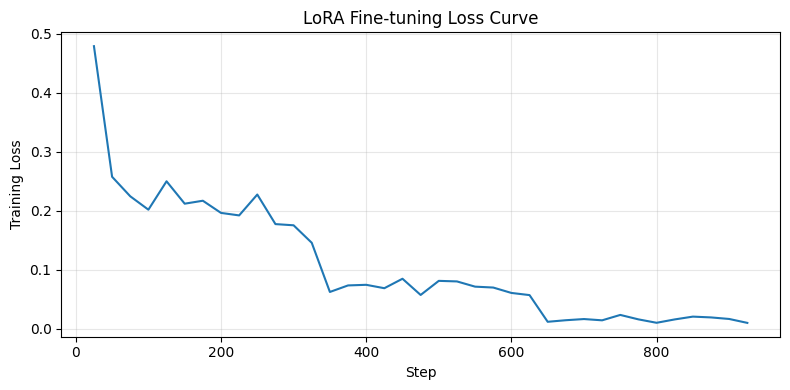

초기 loss 0.4788 → 최종 loss 0.0102


In [18]:
import matplotlib.pyplot as plt

# Trainer의 학습 로그 중 training loss가 기록된 항목만 추출
logs = [l for l in trainer.state.log_history if "loss" in l]

plt.figure(figsize=(8, 4))

plt.plot([l["step"] for l in logs], [l["loss"] for l in logs], linewidth=1.5)

plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("LoRA Fine-tuning Loss Curve")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"초기 loss {logs[0]['loss']:.4f} "  f"→ 최종 loss {logs[-1]['loss']:.4f}")

## 9. 저장 · 로드 · 병합

In [19]:
import os

save_path = "./qwen-lora-korquad"
# 학습된 LoRA adapter 가중치와 설정 파일 저장
lora_model.save_pretrained(save_path)

# 학습에 사용한 tokenizer 설정과 vocabulary 관련 파일 저장
tokenizer.save_pretrained(save_path)

# 저장된 폴더 안의 모든 파일 크기를 합산하여 전체 저장 용량 계산
total = sum(os.path.getsize(os.path.join(save_path, f)) for f in os.listdir(save_path))

print("저장된 파일:", os.listdir(save_path))
print(f"adapter 크기: {total/1024/1024:.1f} MB   (base model 은 약 1 GB)")

저장된 파일: ['adapter_model.safetensors', 'tokenizer_config.json', 'adapter_config.json', 'chat_template.jinja', 'README.md', 'tokenizer.json']
adapter 크기: 44.5 MB   (base model 은 약 1 GB)


### Base Model + LoRA Adapter → 하나의 일반 모델로 병합

In [20]:
from peft import PeftModel

# 원본(base) Causal LM 모델을 다시 로드
# 추론 시 메모리 사용량을 줄이기 위해 float16으로 로드
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(device)

# 저장해 둔 LoRA adapter를 base model에 다시 연결
loaded = PeftModel.from_pretrained(base, save_path)
loaded.eval()

# LoRA adapter 가중치를 base model 가중치에 실제로 합침 → 추론 구조가 단순해지고 속도도 원래 모델 수준에 가까워짐
merged = loaded.merge_and_unload()

# 평가 데이터의 첫 번째 prompt로 답변 생성
pred = batch_generate(merged, [eval_raw[0]["prompt"]])[0]
print(f"질문: {eval_raw[0]['question']}")
print(f"정답: {eval_raw[0]['answer']}")
print(f"예측: {pred}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

질문: 율곡이이 어머니의 이름은?
정답: 신사임당
예측: 신사임당


### 더 좋은 결과를 원한다면
- `TRAIN_SIZE` 를 20000 이상으로 (전체 60K 사용 시 EM 이 더 오릅니다)
- `MODEL_NAME` 을 `Qwen/Qwen2.5-1.5B` 로 (T4 에서도 LoRA 로 학습 가능)
- `EPOCHS` 를 5 로, `LORA_R` 을 32 로

### 참고
- [KorQuAD 공식](https://korquad.github.io/) · [PEFT 문서](https://huggingface.co/docs/peft/en/index)
